# Introduction



เคยสงสัยไหมครับว่าเวลาเราทำ Data Analysis จริง ๆ แล้วเริ่มต้นจากอะไร และจัดการกับข้อมูลอย่างไรเมื่ออยู่ๆมี dataset โยนมาอยู่ตรงหน้าและเราก็ไม่รู้ Domain Context ของข้อมูลนั้น

Notebook นี้เป็นส่วนหนึ่งของการเรียนรู้ด้าน Data Analysis ของผม โดยใช้ชุดข้อมูลเกี่ยวกับ **การนำเข้า–ส่งออกสินค้าประมงของประเทศไทย** จากแพลตฟอร์ม Thackle เป็นกรณีศึกษา โครงการนี้ถูกพัฒนาขึ้นภายใต้ Mini Hackathon ของโครงการ Super AI Engineer SS6

ผมตั้งใจออกแบบ Notebook นี้ให้สามารถอ่านได้ง่ายที่สุดเท่าที่จะทำได้ ลักษณะการเล่าจะคล้ายกับการอ่าน blog post มากกว่าการดูโค้ดเพียงอย่างเดียว เพื่อให้ผู้อ่านทุกคนสามารถเข้าใจแนวคิดของการวิเคราะห์ข้อมูลไปพร้อมกับขั้นตอนที่ทำจริง ถ้ามันอ่านยากใครยากอ่านใช่ไหมครับ ฮาๆๆ

ภายใน Notebook นี้ เราจะค่อย ๆ สำรวจชุดข้อมูลผ่านกระบวนการ Exploratory Data Analysis (EDA) ตั้งแต่การทำความเข้าใจโครงสร้างข้อมูล การตรวจสอบคุณภาพของข้อมูล ไปจนถึงการเลือกเครื่องมือและเทคนิคที่เหมาะสมสำหรับการวิเคราะห์ชุดข้อมูลการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย

สำหรับโปรเจกต์นี้ ผมเลือกใช้ dataset ที่เกี่ยวข้องกับ **การนำเข้าและส่งออกสินค้าประมงของประเทศไทย** ซึ่งเป็นข้อมูลสถิติการค้าระหว่างประเทศที่สะท้อนโครงสร้างการค้าสัตว์น้ำของไทย ทั้งในด้านประเทศคู่ค้า ประเภทสินค้า และมูลค่าการค้าในแต่ละช่วงเวลา

dataset ที่ใช้ในงานนี้อ้างอิงจากแพลตฟอร์ม Thackle
[https://www.thackle.or.th/en/dataset/93](https://www.thackle.or.th/en/dataset/93)

ชุดข้อมูลนี้แสดงข้อมูล **การนำเข้าและส่งออกสินค้าประมงของประเทศไทย** โดยมีการจำแนกข้อมูลตามองค์ประกอบสำคัญ ได้แก่

* ประเทศคู่ค้า
* ประเภทสินค้า (HS Code)
* ปริมาณและน้ำหนักสินค้า
* มูลค่าการค้า
* เดือนและปีของการทำธุรกรรมการค้า

สินค้าที่อยู่ใน dataset ครอบคลุมกลุ่ม **สัตว์น้ำและผลิตภัณฑ์ประมง** เช่น

* ปลา
* กุ้ง
* หอย
* ปลาหมึก
* สัตว์น้ำมีชีวิต
* ผลิตภัณฑ์แปรรูปจากสัตว์น้ำ

ด้วยโครงสร้างข้อมูลลักษณะนี้ เราสามารถนำข้อมูลไปใช้วิเคราะห์โครงสร้างการค้าประมงของประเทศไทยในหลายมิติ เช่น

* ประเทศใดเป็น **ตลาดส่งออกสินค้าประมงสำคัญของไทย**
* ไทย **นำเข้าสัตว์น้ำประเภทใดมากที่สุด**
* โครงสร้างการค้าสัตว์น้ำของไทยเป็น **Net Exporter หรือ Net Importer** ในสินค้าแต่ละประเภท
* การค้าสัตว์น้ำ **มีแนวโน้มเปลี่ยนแปลงตามฤดูกาลหรือไม่**




# Data Dictionary

| Field           | Description                           |
| --------------- | ------------------------------------- |
| year            | ปีของข้อมูล (พ.ศ.)                    |
| month           | เดือนของข้อมูล (1–12)                 |
| heading11       | รหัสสินค้า HS Code สำหรับสินค้าประมง  |
| countryID       | รหัสประเทศคู่ค้า                      |
| countryNameTH   | ชื่อประเทศคู่ค้า                      |
| weight          | น้ำหนักสินค้า (กิโลกรัม × 1,000)      |
| quantity        | จำนวนสินค้า                           |
| price           | มูลค่าการค้า (บาท × 1,000,000)        |
| tradeflow       | ประเภทการค้า (1 = Import, 2 = Export) |
| productDetailEN | รายละเอียดสินค้า (ภาษาอังกฤษ)         |
| productDetailTH | รายละเอียดสินค้า (ภาษาไทย)            |
| ETL_DATE        | วันที่นำข้อมูลเข้าสู่ระบบ             |


# Analytical Questions

เพื่อสำรวจรูปแบบการค้าสินค้าประมงของประเทศไทยจาก dataset นี้ โครงการได้กำหนดโจทย์การวิเคราะห์ไว้ 3 ประเด็นหลัก ซึ่งเราจะพยายามหาคำตอบผ่านกระบวนการ Exploratory Data Analysis

### ข้อ 1 — ตลาดส่งออกสินค้าประมงของไทยอยู่ที่ไหน?

**Major Trading Partners**

จากข้อมูลมูลค่าการค้า เราจะสร้างกราฟเพื่อสำรวจว่า

* ประเทศใดเป็น **ตลาดส่งออกสินค้าประมงสำคัญของไทย**
* ประเทศใดเป็น **แหล่งนำเข้าสัตว์น้ำหลักของไทย**
* ประเทศใดที่ไทยมี **ดุลการค้าเกินดุลหรือขาดดุล** อย่างชัดเจน


### ข้อ 2 — สินค้าประมงชนิดใดคือหัวใจของการค้าไทย?

**Fisheries Product Structure**

วิเคราะห์โครงสร้างสินค้าประมงของไทย โดยจัดกลุ่มตาม **HS Code**

เพื่อแสดงให้เห็นว่า

* สินค้าประเภทใดที่ไทย **ส่งออกมากกว่านำเข้า (Net Export)**
* สินค้าประเภทใดที่ไทย **ต้องพึ่งพาการนำเข้า (Net Import)**


### ข้อ 3 — การค้าสัตว์น้ำมีฤดูกาลหรือไม่?

**Seasonal Trade Pattern**

จากข้อมูลรายเดือนตลอดปี 2568 เราจะวิเคราะห์แนวโน้มการค้าเพื่อดูว่า

* แนวโน้ม **Import และ Export** เปลี่ยนแปลงอย่างไรในแต่ละเดือน
* เดือนใดเป็น **ช่วงการค้าสูงสุด (Peak)** และ **ช่วงการค้าต่ำสุด (Low)**

พร้อมตั้งสมมติฐานเพื่ออธิบายรูปแบบที่พบ เช่น

* ฤดูกาลจับสัตว์น้ำ
* ฤดูกาลเพาะเลี้ยง
* ความต้องการของตลาดโลก
* เทศกาลการบริโภค

# Setting up

ในขั้นตอนแรก เราจะทำการเตรียมเครื่องมือและโหลดชุดข้อมูลสำหรับการวิเคราะห์ โดยผมได้ทำการอัปโหลด dataset ไว้บน GitHub เพื่อให้ง่ายต่อการเข้าถึงและลดปัญหาเรื่อง path ของไฟล์ที่อาจแตกต่างกันในแต่ละเครื่อง

เราจะใช้ Pandas เป็นเครื่องมือหลักในการจัดการข้อมูล ซึ่งสามารถมองได้ว่าเป็นการทำงานกับข้อมูลในลักษณะคล้ายกับ Excel แต่มีความยืดหยุ่นมากกว่าสำหรับงานวิเคราะห์ข้อมูลด้วย Python

สำหรับการแสดงผลเชิงภาพ เราจะใช้ Matplotlib เพื่อสร้างกราฟและ visualizations ต่าง ๆ ที่ช่วยให้สามารถมองเห็นรูปแบบและแนวโน้มของข้อมูลได้ชัดเจนขึ้น

In [78]:
!wget https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

--2026-03-20 16:55:50--  https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Phonbopit/sarabun-webfont/master/fonts/thsarabunnew-webfont.ttf [following]
--2026-03-20 16:55:50--  https://raw.githubusercontent.com/Phonbopit/sarabun-webfont/master/fonts/thsarabunnew-webfont.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 98308 (96K) [application/octet-stream]
Saving to: ‘thsarabunnew-webfont.ttf’

thsarabunnew-webfon 100%[===================>]  96.00K  --.-KB/s    in 0.01s   

2026-03-20 16:55:50 (7.97 MB/s) - ‘t

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import calendar

fm.fontManager.addfont('thsarabunnew-webfont.ttf')
plt.rc('font', family='TH Sarabun New')


%matplotlib inline

หลังจากนำเข้าไลบรารีที่จำเป็นแล้ว เราจะทำการโหลด dataset จากไฟล์ CSV เพื่อเตรียมข้อมูลสำหรับขั้นตอนการทำความสะอาดข้อมูล (Data Cleaning) และการวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis) ในลำดับถัดไป

In [51]:
DATASET_SRC = "https://github.com/northlnwza/SuperAIEngineer_SS6/raw/sebsvt/00-mini-hackathon/1-data-cleansing-challenge/datasets/import_export.csv"
df = pd.read_csv(DATASET_SRC)

# Initial Data Exploration

ก่อนที่จะเริ่มทำความสะอาดหรือวิเคราะห์ข้อมูล เราจะสำรวจ dataset เบื้องต้นเพื่อทำความเข้าใจโครงสร้างของข้อมูลก่อน โดยเริ่มจากการดูตัวอย่างข้อมูลบางส่วนและตรวจสอบขนาดของ dataset

เราจะใช้ df.head() เพื่อแสดงตัวอย่างข้อมูล 5 แถวแรก

In [52]:
df.head(5)

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
0,2568,8,1062000002,BJ,เบนิน,33,90,48080,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
1,2568,8,1062000002,MU,มอริเชียส,10,50,44147,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
2,2568,8,1062000002,BR,บราซิล,8,150,47068,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
3,2568,8,1062000002,EG,อียิปต์,315,100,225663,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
4,2568,9,1062000002,KE,เคนยา,49,200,74954,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59


จากนั้นตรวจสอบโครงสร้างของข้อมูลด้วย df.info() ซึ่งช่วยให้เห็นจำนวนแถว ชนิดข้อมูลของแต่ละคอลัมน์ และจำนวนค่าที่ไม่เป็น null

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42057 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42057 non-null  int64 
 1   month            42057 non-null  int64 
 2   heading11        42057 non-null  int64 
 3   countryID        42032 non-null  object
 4   countryNameTH    42057 non-null  object
 5   weight           42057 non-null  int64 
 6   quantity         42057 non-null  int64 
 7   price            42057 non-null  int64 
 8   tradeflow        42057 non-null  int64 
 9   productDetailEN  42057 non-null  object
 10  productDetailTH  42057 non-null  object
 11  ETL_DATE         42057 non-null  object
dtypes: int64(7), object(5)
memory usage: 3.9+ MB


ผลลัพธ์แสดงให้เห็นว่า dataset นี้มี
- 42,057 rows
- 12 columns

โดยชนิดข้อมูลแบ่งเป็น
- int64 จำนวน 7 คอลัมน์
- object (string) จำนวน 5 คอลัมน์


จากการตรวจสอบพบว่าเกือบทุกคอลัมน์มีข้อมูลครบถ้วน ยกเว้นคอลัมน์ `countryID `ที่มีค่า missing อยู่ 25 แถว

เมื่อเทียบกับจำนวนข้อมูลทั้งหมดแล้ว คิดเป็นประมาณ 0.06% ของ dataset ซึ่งถือว่าเป็นสัดส่วนที่น้อยมาก

ในขั้นตอนนี้เรายังไม่ทำการลบข้อมูลทันที แต่จะนำประเด็นนี้ไปตรวจสอบเพิ่มเติมในขั้นตอน Data Cleaning ว่าสามารถเติมค่าที่หายไปได้หรือควรลบข้อมูลดังกล่าวออก

หลังจากนั้น เราจะใช้ df.describe() เพื่อดู สถิติเบื้องต้นของข้อมูลเชิงตัวเลข เช่น ค่าเฉลี่ย ค่าต่ำสุด ค่าสูงสุด และการกระจายของข้อมูล

In [54]:
df.describe()

,year,month,heading11,weight,quantity,price,tradeflow
count,42057.0,42057.000000,4.205700e+04,4.205700e+04,4.205700e+04,4.205700e+04,42057.000000
mean,2568.0,6.481109,9.223337e+09,8.877408e+04,3.179653e+05,8.930086e+06,1.685237
std,0.0,3.443259,7.461236e+09,4.523216e+05,1.268477e+07,4.082484e+07,0.464427
min,2568.0,1.000000,1.062000e+09,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
25%,2568.0,3.000000,3.038919e+09,8.700000e+01,2.150000e+02,4.400500e+04,1.000000
50%,2568.0,6.000000,3.074390e+09,2.700000e+03,3.390000e+03,5.541010e+05,2.000000
75%,2568.0,9.000000,1.604203e+10,2.600000e+04,3.740000e+04,3.534184e+06,2.000000
max,2568.0,12.000000,4.103200e+10,1.868457e+07,2.375726e+09,1.157586e+09,2.000000


จากผลลัพธ์ของ df.describe() เราสามารถดู สถิติเบื้องต้นของคอลัมน์ที่เป็นตัวเลข เพื่อทำความเข้าใจลักษณะการกระจายของข้อมูลใน dataset ได้ โดยตารางด้านบนแสดงค่าทางสถิติสำคัญ เช่น ค่าเฉลี่ย (mean) ค่ากลาง (median) ค่าต่ำสุด (min) ค่าสูงสุด (max) และการกระจายตัวของข้อมูล

ในคอลัมน์ year พบว่าค่าทั้งหมดเป็นปี 2568 ซึ่งหมายความว่าชุดข้อมูลนี้ครอบคลุมข้อมูลการค้าประมงของประเทศไทยในปีเดียว ขณะที่คอลัมน์ month มีค่าตั้งแต่ 1 ถึง 12 แสดงว่าข้อมูลครอบคลุมทั้ง 12 เดือนของปีดังกล่าว

สำหรับตัวแปรด้านปริมาณการค้า ได้แก่ weight, quantity และ price จะเห็นได้ว่าค่าเฉลี่ย (mean) มีค่ามากกว่าค่ากลาง (50% หรือ median) อย่างชัดเจน ซึ่งชี้ให้เห็นว่าการกระจายของข้อมูลมีลักษณะ เอียงไปทางค่าที่สูง (right-skewed distribution) หรือก็คือ มีธุรกรรมบางรายการที่มีปริมาณหรือตัวเลขมูลค่าสูงมาก ทำให้ค่าเฉลี่ยเพิ่มขึ้น

นอกจากนี้ค่าต่ำสุดของตัวแปร weight, quantity และ price เป็น 0 ซึ่งอาจเกิดจากหลายสาเหตุ เช่น การบันทึกข้อมูลที่เป็นศูนย์จริง หรือค่าที่ขาดหายไปในระบบ จึงควรตรวจสอบเพิ่มเติมในขั้นตอน Data Cleaning

ในส่วนของคอลัมน์ tradeflow ซึ่งใช้รหัสตัวเลขเพื่อระบุประเภทการค้า (1 = Import, 2 = Export) พบว่าค่าเฉลี่ยอยู่ที่ประมาณ 1.68 และค่ากลางอยู่ที่ 2 ซึ่งบ่งชี้ว่าใน dataset นี้มีรายการ การส่งออก (Export) มากกว่าการนำเข้า (Import) เล็กน้อย

เราจะทำการเปลี่ยนค่าจาก 1,2 เป็น import, export เพื่อง่ายแก่การเข้าใจ

In [55]:
df["tradeflow"] = df["tradeflow"].replace({1: "Import", 2: "Export"})

เสร็จแล้วเราจะลองเทียบสัดส่วนของการนำเข้าและส่งออก

tradeflow
Export    28819
Import    13238
Name: count, dtype: int64


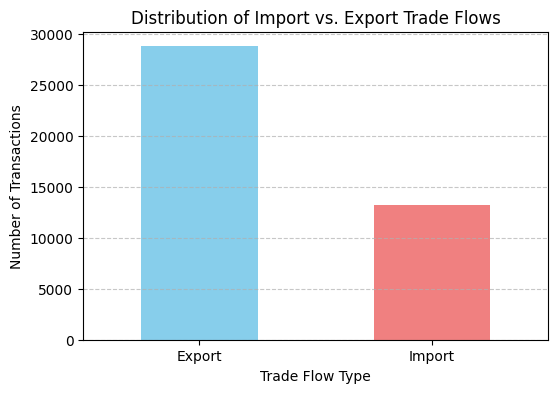

In [56]:
tradeflow_counts = df['tradeflow'].value_counts()
print(tradeflow_counts)

plt.figure(figsize=(6, 4))
tradeflow_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Import vs. Export Trade Flows')
plt.xlabel('Trade Flow Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

เมื่อทำการตรวจสอบจำนวนรายการของแต่ละประเภทด้วย value_counts() พบว่า

- Export มีจำนวน 28,819 รายการ
- Import มีจำนวน 13,238 รายการ

ข้อมูลดังกล่าวยืนยันว่าธุรกรรมใน dataset นี้ ส่วนใหญ่เป็นการส่งออก ซึ่งสอดคล้องกับลักษณะของอุตสาหกรรมประมงของประเทศไทยที่มีบทบาทเป็นประเทศผู้ส่งออกสินค้าประมงในตลาดโลก

# Data Cleansing

ก่อนเข้าสู่ขั้นตอนการวิเคราะห์เชิงลึก จำเป็นต้องประเมินคุณภาพของข้อมูลอย่างเป็นระบบ เพื่อให้มั่นใจว่าผลลัพธ์ที่ได้สะท้อนพฤติกรรมการค้าจริง ไม่ใช่ artifact ที่เกิดจากความผิดพลาดของข้อมูล

ในบริบทของข้อมูลการค้าระหว่างประเทศ ความไม่สมบูรณ์ของข้อมูล (data imperfection) เป็นสิ่งที่พบได้เป็นปกติ ไม่ว่าจะเป็นค่าที่หายไป การบันทึกค่าเป็นศูนย์ หรือความไม่สอดคล้องของรูปแบบข้อมูล ดังนั้น เป้าหมายของขั้นตอนนี้ไม่ใช่การ “ทำให้ข้อมูลสะอาดสมบูรณ์แบบ” แต่คือการ “เข้าใจข้อจำกัดของข้อมูล และจัดการอย่างมีเหตุผล”

### Data Type Validation

ขั้นตอนแรกของการตรวจสอบคุณภาพข้อมูลคือการยืนยันว่า **ชนิดข้อมูล (data type)** ของแต่ละตัวแปรสอดคล้องกับลักษณะการใช้งานจริง

ในงานวิเคราะห์ข้อมูล ชนิดข้อมูลมีผลโดยตรงต่อความสามารถในการประมวลผล เช่น:
- ตัวแปรเชิงตัวเลข (numeric) จำเป็นต้องอยู่ในรูปแบบที่สามารถคำนวณได้ เพื่อใช้ในการรวม (aggregation) หรือคำนวณสถิติ
- ตัวแปรเวลา เช่น เดือนหรือปี ควรอยู่ในรูปแบบที่สามารถจัดเรียง (ordering) และวิเคราะห์แนวโน้มได้
- ตัวแปรเชิงหมวดหมู่ (categorical) ควรมีรูปแบบที่สม่ำเสมอ เพื่อลดความคลาดเคลื่อนในการจัดกลุ่มข้อมูล

หากข้อมูลถูกจัดเก็บใน data type ที่ไม่เหมาะสม เช่น:
- ตัวเลขถูกเก็บเป็น string
- วันที่ถูกเก็บเป็นข้อความ

จะส่งผลให้:
- ไม่สามารถคำนวณเชิงตัวเลขได้อย่างถูกต้อง
- ไม่สามารถเรียงลำดับข้อมูลตามเวลาได้
- เพิ่มความเสี่ยงในการเกิดข้อผิดพลาดในขั้นตอนการวิเคราะห์

ดังนั้น ในขั้นตอนนี้จึงทำการตรวจสอบและยืนยันว่า data type ของแต่ละคอลัมน์ถูกต้อง และพร้อมสำหรับการนำไปใช้ในขั้นตอนถัดไป


In [57]:
data_info = []

for col in df.columns:
    col_type = df[col].dtype
    sample_values = []

    if col_type == 'object':
        unique_count = df[col].nunique()
        if unique_count < 10: # If few unique values, show all
            sample_values = df[col].dropna().unique().tolist()
        else: # Otherwise, show top 5 value counts
            sample_values = df[col].value_counts().head().index.tolist()
    else: # For numeric types, show a few random samples
        if not df[col].dropna().empty:
            sample_values = df[col].dropna().sample(min(5, len(df[col].dropna()))).tolist()
        else:
            sample_values = "No non-null values to sample."

    data_info.append({
        'Column': col,
        'Data Type': str(col_type),
        'Sample Values': sample_values
    })

df_info = pd.DataFrame(data_info)
display(df_info)

,Column,Data Type,Sample Values
0,year,int64,"[2568, 2568, 2568, 2568, 2568]"
1,month,int64,"[3, 2, 10, 11, 8]"
2,heading11,int64,"[21039029000, 16041419000, 3034400000, 3011199..."
3,countryID,object,"[JP, CN, US, HK, MY]"
4,countryNameTH,object,"[ญี่ปุ่น, จีน, สหรัฐอเมริกา, ฮ่องกง, มาเลเซีย]"
5,weight,int64,"[550, 504, 275, 48923, 2]"
6,quantity,int64,"[12, 1850, 385512, 24540, 200]"
7,price,int64,"[99539, 1650228, 84253, 71600, 18043]"
8,tradeflow,object,"[Import, Export]"
9,productDetailEN,object,"[(blank), Other, #NAME?, Fish sauce, Surimi meat]"


จากการตรวจสอบชนิดข้อมูลของแต่ละคอลัมน์ พบว่าส่วนใหญ่มี data type ที่สอดคล้องกับลักษณะการใช้งานแล้ว  
เช่น ตัวแปรเชิงตัวเลข (`year`, `month`, `price`) ถูกจัดเก็บในรูปแบบ numeric ซึ่งสามารถนำไปใช้คำนวณได้ทันที

อย่างไรก็ตาม พบว่าคอลัมน์ `ETL_DATE` ถูกจัดเก็บในรูปแบบ `object` ทั้งที่ข้อมูลภายในเป็นวันและเวลา (datetime)

การเก็บข้อมูลเวลาในรูปแบบ string อาจทำให้เกิดข้อจำกัด เช่น:
- ไม่สามารถเรียงลำดับตามเวลาได้อย่างถูกต้อง
- ไม่สามารถดึงองค์ประกอบของเวลา เช่น วัน เดือน ปี หรือชั่วโมง ออกมาใช้ได้
- ไม่สามารถนำไปใช้วิเคราะห์เชิงเวลา (time-based analysis) ได้อย่างมีประสิทธิภาพ

ดังนั้น ในขั้นตอนนี้จึงทำการแปลง `ETL_DATE` ให้อยู่ในรูปแบบ `datetime`  
เพื่อให้สามารถใช้งานข้อมูลเวลาได้อย่างถูกต้องและรองรับการวิเคราะห์ในขั้นตอนถัดไป

In [58]:
df['ETL_DATE'] = pd.to_datetime(df['ETL_DATE'], format='%m/%d/%Y %H:%M')
df['ETL_DATE']

,ETL_DATE
0,2026-12-03 05:59:00
1,2026-12-03 05:59:00
2,2026-12-03 05:59:00
3,2026-12-03 05:59:00
4,2026-12-03 05:59:00
...,...
42052,2026-12-03 05:59:00
42053,2026-12-03 05:59:00
42054,2026-12-03 05:59:00
42055,2026-12-03 05:59:00


ตอนนี้ dtype เป็น datetime แล้ว :)

ต่อจากขั้นตอนการตรวจสอบข้อมูลเบื้องต้นที่เราทำกันไปพบว่าคอลัมน์ `countryID` มีค่า missing จำนวนเล็กๆ (~0.06% ของข้อมูลทั้งหมด)

เพื่อหลีกเลี่ยงการลบข้อมูลโดยไม่จำเป็นเราจึงจะทำการตรวจสอบเพิ่มเติมว่า missing value เหล่านี้สามารถกู้คืน (recover) ได้ไหม

ทำการ filter เฉพาะแถวที่ `countryID` เป็นค่าว่าง และตรวจสอบค่าใน `countryNameTH`



In [59]:
null_country_id_df = df[df['countryID'].isnull()]
country_name_null_counts = null_country_id_df['countryNameTH'].value_counts().reset_index()
country_name_null_counts.columns = ['countryNameTH', 'count_of_null_countryID']
country_name_null_counts

,countryNameTH,count_of_null_countryID
0,นามิเบีย,25


ผลลัพธ์พบว่า ข้อมูลที่ `countryID` หายไปทั้งหมดสอดคล้องกับประเทศเดียว คือ **“นามิเบีย”**

จากนั้นทำการตรวจสอบเพิ่มเติมใน dataset เดิมว่า record อื่นๆของ “นามิเบีย” ที่มี `countryID` ที่ถูกต้องไหม

In [60]:
df[df['countryNameTH'] == 'นามิเบีย']['countryID']

,countryID
5580,NaN
6118,NaN
6956,NaN
6991,NaN
8366,NaN
8380,NaN
8546,NaN
20189,NaN
20223,NaN
20251,NaN


ผลลัพธ์คือไม่พบ `countryID` สำหรับ “นามิเบีย” ในทุกแถว แสดงว่าข้อมูลประเทศนี้ถูกบันทึกไม่ครบทั้งชุดเลย

เนื่องจาก `countryNameTH` ระบุประเทศได้ชัดเจน และ `countryID` มีรูปแบบเป็นรหัสตัวอักษร 2 ตัว เราจึงสามารถเติมข้อมูลที่หายไปโดยอ้างอิงจากมาตรฐานสากลได้ ซึ่งในกรณีนี้ใช้ **ISO 3166-1 alpha-2 country code**  
ซึ่งเป็นมาตรฐานรหัสประเทศ 2 ตัวอักษร

สำหรับประเทศ “นามิเบีย” รหัสก็คือ `NA`


In [61]:
df.loc[
    (df["countryID"].isnull()) & (df["countryNameTH"] == "นามิเบีย"),
    "countryID"
] = "NA"


หลังจากทำการเติมค่า `countryID` สำหรับประเทศนามิเบียเรียบร้อยแล้ว  
จำเป็นต้องตรวจสอบความถูกต้องของการแก้ไข เพื่อให้มั่นใจว่าไม่มีข้อผิดพลาดหลงเหลืออยู่ในข้อมูล

การตรวจสอบประกอบด้วย 2 ส่วน:

1. ตรวจสอบว่าไม่มีค่า missing (`null`) ในคอลัมน์ `countryID` อีกต่อไป  
2. ตรวจสอบว่า record ของ “นามิเบีย” ถูกเติมค่า `countryID` อย่างถูกต้องและสม่ำเสมอ

ขั้นตอนนี้มีความสำคัญ เนื่องจากช่วยยืนยันว่า data cleaning ที่ดำเนินการไปไม่ได้สร้าง inconsistency ใหม่ใน dataset และทำให้ข้อมูลพร้อมสำหรับการวิเคราะห์ในขั้นตอนถัดไป

In [62]:
# ตรวจสอบ null ทั้งคอลัมน์
df["countryID"].isnull().sum()

np.int64(0)

In [63]:
df[df["countryNameTH"] == "นามิเบีย"]["countryID"].unique()

array(['NA'], dtype=object)

หลังจากดำเนินการเติมค่า `countryID` สำหรับข้อมูลที่ขาดหายพบว่า

- ไม่พบค่า missing (`null`) ในคอลัมน์ `countryID` อีกต่อไป (จำนวนเท่ากับ 0)
- ข้อมูลของประเทศ “นามิเบีย” ถูกเติมค่า `countryID` เป็น `"NA"` ครบถ้วนในทุก record

ผลลัพธ์ดังกล่าวยืนยันว่าการแก้ไขข้อมูลในขั้นตอนก่อนหน้าดำเนินการได้อย่างถูกต้องและไม่พบความไม่สอดคล้อง (inconsistency) ภายในคอลัมน์นี้

เราจะตรวจสอบเพิ่มเติมนิดนึงว่า `countryID` แต่ละค่าถูก mapping ไปยัง `countryNameTH` เพียงค่าเดียวหรือไม่ เพื่อกรณีที่ว่า TH ดันมีค่า map ไปหาที่อื่นอีก


In [64]:
country_check = df.groupby("countryID")["countryNameTH"].nunique()
country_check[country_check > 1]

,countryNameTH
countryID,


ผลลัพธ์ไม่พบความไม่สอดคล้องของการ mapping ระหว่าง `countryID` และ `countryNameTH`  
แสดงว่าข้อมูลประเทศมีความถูกต้องและสามารถนำไปใช้งานในการวิเคราะห์ได้อย่างมั่นใจ

ก่อนเข้าสู่ขั้นตอนการวิเคราะห์หลัก จำเป็นต้องตรวจสอบตัวแปรสำคัญที่ใช้ในการคำนวณโดยตรง ได้แก่

- `weight` (น้ำหนักสินค้า)
- `quantity` (จำนวนสินค้า)
- `price` (มูลค่าการค้า)

เนื่องจากตัวแปรเหล่านี้เป็นแกนหลักของการวิเคราะห์ในทุกโจทย์ หากมีความผิดปกติอาจส่งผลให้ผลลัพธ์คลาดเคลื่อนได้อย่างมีนัยสำคัญ

ดังนั้น ในขั้นตอนนี้จะทำการตรวจสอบใน 3 มิติหลัก ได้แก่

1. การกระจายของข้อมูล (Distribution)  
   เพื่อตรวจสอบลักษณะของข้อมูล เช่น skewness และ outliers

2. ค่าที่เป็นศูนย์ (Zero Values)  
   เพื่อตรวจสอบว่ามี transaction ที่อาจผิดปกติหรือไม่

3. ความสมเหตุสมผลเชิงตรรกะ (Logical Consistency)  
   เช่น กรณีที่มีน้ำหนักหรือจำนวนสินค้า แต่ไม่มีมูลค่าการค้า

การตรวจสอบนี้มีเป้าหมายเพื่อยืนยันว่า dataset มีความพร้อมเพียงพอสำหรับการวิเคราะห์  
โดยไม่จำเป็นต้องปรับแก้เพิ่มเติมในระดับโครงสร้าง


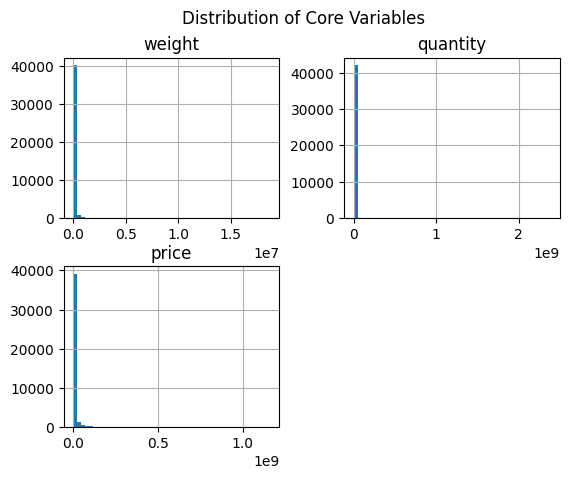

In [65]:
df[["weight", "quantity", "price"]].hist(bins=50)
plt.suptitle("Distribution of Core Variables")
plt.show()

ตัวแปร `weight`, `quantity` และ `price` มีการกระจายแบบ **เบ้ขวาอย่างรุนแรง (Highly Right-Skewed)**  
โดยข้อมูลส่วนใหญ่มีค่าต่ำ และมีธุรกรรมจำนวนน้อยที่มีค่าสูงมาก (extreme outliers)

ลักษณะนี้เป็นไปตามธรรมชาติของข้อมูลการค้า ซึ่งมีทั้งธุรกรรมขนาดเล็กและขนาดใหญ่ปะปนกัน

ดังนั้น ในการวิเคราะห์ขั้นถัดไป:
- จะใช้ **ผลรวม (sum)** เป็น metric หลักแทนค่าเฉลี่ย  
- จะยังไม่ลบ outliers ออก เนื่องจากมีแนวโน้มเป็นข้อมูลจริง

จากการวิเคราะห์การกระจายของข้อมูล พบว่าตัวแปรหลักมีลักษณะเบ้ขวาอย่างรุนแรง และมีค่า outliers อยู่จำนวนหนึ่ง

แม้ว่าลักษณะดังกล่าวจะพบได้ทั่วไปในข้อมูลการค้า  
แต่เพื่อให้มั่นใจว่าค่าที่สูงหรือต่ำผิดปกติเหล่านี้ไม่ได้เกิดจากข้อผิดพลาดของข้อมูล (data error)

จึงจำเป็นต้องทำการตรวจสอบความสมเหตุสมผลเชิงตรรกะ (logical consistency) ของข้อมูลเพิ่มเติม โดยจะทำการตรวจสอบความสัมพันธ์ระหว่างตัวแปรหลัก ได้แก่:

- น้ำหนัก (`weight`)
- จำนวน (`quantity`)
- มูลค่า (`price`)

โดยมุ่งเน้นไปที่กรณีที่อาจสะท้อนความผิดปกติ เช่น:

- มีปริมาณสินค้า แต่ไม่มีมูลค่าการค้า (`price = 0`)
- มีมูลค่าการค้า แต่ไม่มีน้ำหนักสินค้า (`weight = 0`)

ซึ่งอาจบ่งชี้ถึงปัญหาในการบันทึกข้อมูล หรือค่าที่ขาดหายไปในระบบ

In [66]:
df[(df["weight"] > 0) & (df["price"] == 0)]


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
11732,2568,10,3061600000,HK,ฮ่องกง,2,2,0,Export,Cold-water shrimps and prawns (Pandalus spp. ...,กุ้งน้ำเย็น แช่เย็นจนแข็ง,2026-12-03 05:59:00
19875,2568,4,16041110000,NL,เนเธอร์แลนด์,3,3,0,Export,Salmon in airtight contaimers,ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม่บดปรุงแต่งหรือท...,2026-12-03 05:59:00
24246,2568,4,16041510000,NL,เนเธอร์แลนด์,2,2,0,Export,Mackerelin airtight containers,ปลาแมกเคอเรลบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้,2026-12-03 05:59:00
28209,2568,9,16051090090,HK,ฮ่องกง,4,1,0,Export,(blank),ปูที่ปรุงแต่งหรือทำไว้ไม่ให้เสียอื่นๆ,2026-12-03 05:59:00
28289,2568,12,16051090090,HK,ฮ่องกง,3,1,0,Export,(blank),ปูที่ปรุงแต่งหรือทำไว้ไม่ให้เสียอื่นๆ,2026-12-03 05:59:00
28764,2568,4,16052920000,NL,เนเธอร์แลนด์,6,6,0,Export,Shrimp ball,ลูกชิ้นกุ้ง,2026-12-03 05:59:00
30081,2568,4,16055490000,HK,ฮ่องกง,7,1,0,Export,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,2026-12-03 05:59:00
30148,2568,6,16055490000,HK,ฮ่องกง,7,1,0,Export,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,2026-12-03 05:59:00
39337,2568,5,3048990000,AU,ออสเตรเลีย,9,9,0,Export,Other,เนื้อปลาอื่น ๆ สด แช่เย็น หรือแช่เย็นจนแข็ง,2026-12-03 05:59:00
41016,2568,11,16051014090,HK,ฮ่องกง,1,1,0,Export,Other,ปู อื่น ๆ,2026-12-03 05:59:00


In [67]:
df[(df["quantity"] > 0) & (df["price"] == 0)]


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
11732,2568,10,3061600000,HK,ฮ่องกง,2,2,0,Export,Cold-water shrimps and prawns (Pandalus spp. ...,กุ้งน้ำเย็น แช่เย็นจนแข็ง,2026-12-03 05:59:00
19875,2568,4,16041110000,NL,เนเธอร์แลนด์,3,3,0,Export,Salmon in airtight contaimers,ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม่บดปรุงแต่งหรือท...,2026-12-03 05:59:00
24246,2568,4,16041510000,NL,เนเธอร์แลนด์,2,2,0,Export,Mackerelin airtight containers,ปลาแมกเคอเรลบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้,2026-12-03 05:59:00
28209,2568,9,16051090090,HK,ฮ่องกง,4,1,0,Export,(blank),ปูที่ปรุงแต่งหรือทำไว้ไม่ให้เสียอื่นๆ,2026-12-03 05:59:00
28289,2568,12,16051090090,HK,ฮ่องกง,3,1,0,Export,(blank),ปูที่ปรุงแต่งหรือทำไว้ไม่ให้เสียอื่นๆ,2026-12-03 05:59:00
28764,2568,4,16052920000,NL,เนเธอร์แลนด์,6,6,0,Export,Shrimp ball,ลูกชิ้นกุ้ง,2026-12-03 05:59:00
30081,2568,4,16055490000,HK,ฮ่องกง,7,1,0,Export,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,2026-12-03 05:59:00
30148,2568,6,16055490000,HK,ฮ่องกง,7,1,0,Export,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,2026-12-03 05:59:00
39337,2568,5,3048990000,AU,ออสเตรเลีย,9,9,0,Export,Other,เนื้อปลาอื่น ๆ สด แช่เย็น หรือแช่เย็นจนแข็ง,2026-12-03 05:59:00
41016,2568,11,16051014090,HK,ฮ่องกง,1,1,0,Export,Other,ปู อื่น ๆ,2026-12-03 05:59:00


In [68]:
df[(df["price"] > 0) & (df["weight"] == 0)]

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
31,2568,12,1062000002,US,สหรัฐอเมริกา,0,4,57067,Import,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,2026-12-03 05:59:00
76,2568,12,1062000003,MV,มัลดีฟส์,0,30,1177,Export,Taiwan snapping turtles,ตะพาบน้ำไต้หวันมีชีวิต,2026-12-03 05:59:00
176,2568,8,2109300000,KR,เกาหลีใต้,0,1,32,Export,(blank),เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลาน...,2026-12-03 05:59:00
184,2568,11,2109300000,KR,เกาหลีใต้,0,1,32,Export,(blank),เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลาน...,2026-12-03 05:59:00
233,2568,2,3011191000,RE,รียูเนี่ยน,0,10,185,Export,#NAME?,ปลาคาร์ป สวยงามมีชีวิต (แฟนซีคาร์ป) (ไซพรีนสคา...,2026-12-03 05:59:00
...,...,...,...,...,...,...,...,...,...,...,...,...
41646,2568,6,3063391000,QA,กาตาร์,0,100,1926,Export,Live,ปู มีชีวิต,2026-12-03 05:59:00
41680,2568,8,3063391000,LY,ลิยานอาหรับจามาฐิยา,0,100,2442,Export,Live,ปู มีชีวิต,2026-12-03 05:59:00
41711,2568,10,3063391000,PL,โปแลนด์,0,200,947,Export,Live,ปู มีชีวิต,2026-12-03 05:59:00
41960,2568,6,3091000000,JP,ญี่ปุ่น,0,0,10,Export,Of fish,ของจากปลา,2026-12-03 05:59:00


จากการตรวจสอบความสมเหตุสมผลของข้อมูล พบความไม่สอดคล้องในบางกรณี ได้แก่:

- มีปริมาณหรือจำนวนสินค้า แต่ไม่มีมูลค่าการค้า (`price = 0`)
- มีมูลค่าการค้า แต่ไม่มีน้ำหนักสินค้า (`weight = 0`)

ลักษณะดังกล่าวอาจเกิดจาก:
- ข้อมูลที่ขาดหาย (missing values) แต่ถูกบันทึกเป็นศูนย์
- หรือข้อผิดพลาดในกระบวนการบันทึกข้อมูล (data entry / system error)

อย่างไรก็ตาม เมื่อพิจารณาในภาพรวม:
- จำนวนข้อมูลที่มีความผิดปกติดังกล่าวมีสัดส่วนค่อนข้างน้อยเมื่อเทียบกับ dataset ทั้งหมด  
- และไม่ได้กระจุกตัวในกลุ่มประเทศหรือสินค้าใดอย่างมีนัยสำคัญ

ดังนั้น ในโปรเจกต์นี้:

- จะ **ยังคงเก็บข้อมูลทั้งหมดไว้** เพื่อไม่ให้สูญเสียข้อมูลที่อาจมีความหมาย  
- และจะใช้ **มูลค่าการค้า (`price`) เป็นตัวแปรหลัก** ในการวิเคราะห์  
- โดยตีความผลลัพธ์ด้วยความระมัดระวังในกรณีที่เกี่ยวข้องกับค่าผิดปกติ
แม้จะพบความไม่สมบูรณ์ของข้อมูลในบางส่วน  
แต่โดยรวม dataset ยังมีคุณภาพเพียงพอสำหรับการวิเคราะห์เชิงสำรวจ (EDA)  
และสามารถนำไปใช้ตอบคำถามเชิงธุรกิจในขั้นตอนถัดไปได้

# Exploratory Data Analysis

หลังจากตรวจสอบและเตรียมข้อมูลเรียบร้อยแล้ว  
ขั้นตอนถัดไปคือการวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis: EDA)

โดยเป้าหมายของการวิเคราะห์ในส่วนนี้ ไม่ใช่เพียงการสำรวจรูปแบบของข้อมูล  
แต่เป็นการใช้ข้อมูลเพื่อตอบคำถามทางธุรกิจที่กำหนดไว้ ได้แก่:

1. ตลาดส่งออกสินค้าประมงของไทยอยู่ที่ไหน  
2. สินค้าประมงชนิดใดเป็นหัวใจของการค้า  
3. การค้าสัตว์น้ำมีลักษณะเป็นฤดูกาลหรือไม่  

เพื่อให้การวิเคราะห์มีความสอดคล้องและสามารถเปรียบเทียบได้อย่างเหมาะสม  
การวิเคราะห์ทั้งหมดจะใช้ **มูลค่าการค้า (`price`) เป็น metric หลัก**  
เนื่องจากข้อมูลมีลักษณะการกระจายแบบ skewed และไม่เหมาะสมกับการใช้ค่าเฉลี่ย

จากนี้ไป เราจะเริ่มตอบคำถามทีละข้ออย่างเป็นระบบ

## Major Trading Partners Analysis

ในส่วนนี้ จะทำการวิเคราะห์ภูมิทัศน์การค้าระหว่างประเทศในหมวดสินค้าประมงและสัตว์น้ำของประเทศไทย โดยใช้ข้อมูลมูลค่าการนำเข้าและการส่งออก จำแนกตามประเทศคู่ค้า (Country of Origin/Destination)

**วัตถุประสงค์ของการวิเคราะห์:**
1. **ระบุโครงสร้างตลาดส่งออกหลัก (Export Markets):** เพื่อประเมินสัดส่วนการพึ่งพิงตลาดต่างประเทศ และค้นหาประเทศที่เป็นแหล่งรายได้หลักของอุตสาหกรรม
2. **ระบุแหล่งอุปทานสำคัญ (Import Sources):** เพื่อทำความเข้าใจทิศทางการไหลเข้าของวัตถุดิบต้นน้ำ และประเมินความเสี่ยงด้านห่วงโซ่อุปทาน (Supply Chain Risks) จากประเทศต้นทาง
3. **ประเมินเสถียรภาพดุลการค้า (Trade Balance Analysis):** เพื่อคำนวณส่วนต่างระหว่างกระแสเงินสดรับและจ่าย (Net Trade Value) และระบุกลุ่มประเทศที่ประเทศไทยมีความได้เปรียบหรือเสียเปรียบเชิงโครงสร้าง

**ระเบียบวิธีวิเคราะห์ (Analytical Approach):**
ดำเนินการรวมมูลค่าการค้า (Price) แยกตามประเภทธุรกรรม (Import/Export) ในแต่ละประเทศคู่ค้า (Country Name) และนำเสนอผ่านรูปแบบแผนภูมิแท่งแนวนอน (Horizontal Bar Chart) เพื่อเปรียบเทียบลำดับความสำคัญ (Rankings) ของกลุ่มประเทศคู่ค้า Top 10 ในแต่ละมิติ

In [108]:
country_trade = df.pivot_table(
    index='countryNameTH',
    columns='tradeflow',
    values='price',
    aggfunc='sum'
).fillna(0).reset_index()

country_trade['Net_Balance'] = country_trade['Export'] - country_trade['Import']

top_exports = country_trade.nlargest(10, 'Export').sort_values('Export', ascending=True)
top_imports = country_trade.nlargest(10, 'Import').sort_values('Import', ascending=True)
top_surplus = country_trade.nlargest(10, 'Net_Balance').sort_values('Net_Balance', ascending=True)

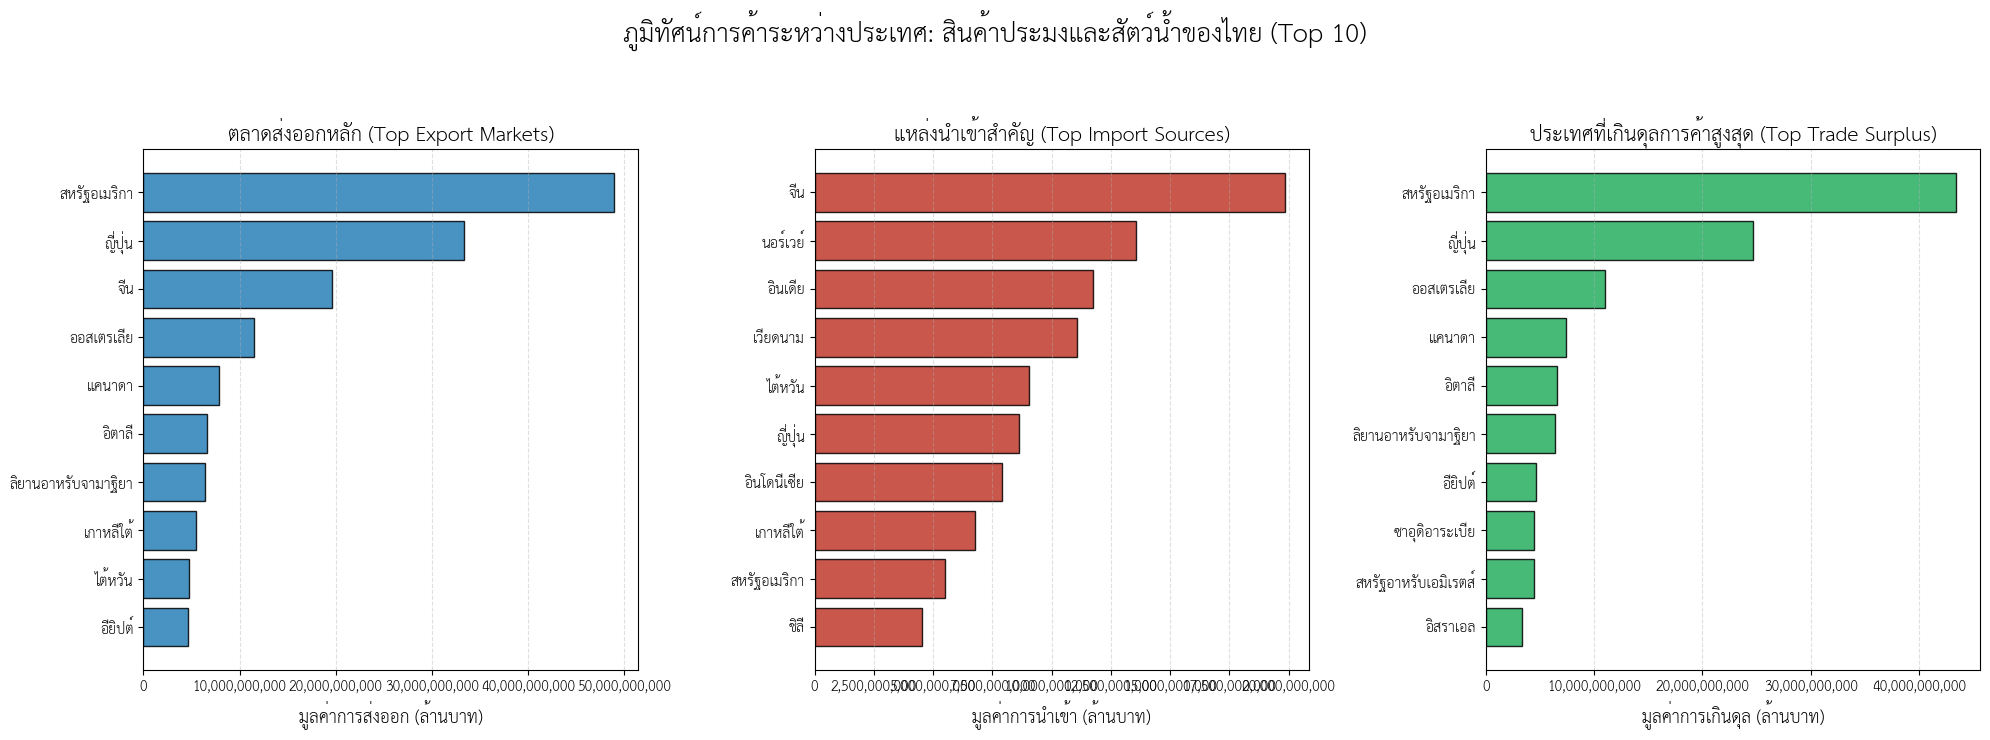

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
fig.suptitle('ภูมิทัศน์การค้าระหว่างประเทศ: สินค้าประมงและสัตว์น้ำของไทย (Top 10)', fontsize=18, fontweight='bold', y=1.05)

axes[0].barh(top_exports['countryNameTH'], top_exports['Export'], color='#2980b9', edgecolor='black', alpha=0.85)
axes[0].set_title('ตลาดส่งออกหลัก (Top Export Markets)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('มูลค่าการส่งออก (ล้านบาท)', fontsize=12)

axes[1].barh(top_imports['countryNameTH'], top_imports['Import'], color='#c0392b', edgecolor='black', alpha=0.85)
axes[1].set_title('แหล่งนำเข้าสำคัญ (Top Import Sources)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('มูลค่าการนำเข้า (ล้านบาท)', fontsize=12)

axes[2].barh(top_surplus['countryNameTH'], top_surplus['Net_Balance'], color='#27ae60', edgecolor='black', alpha=0.85)
axes[2].set_title('ประเทศที่เกินดุลการค้าสูงสุด (Top Trade Surplus)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('มูลค่าการเกินดุล (ล้านบาท)', fontsize=12)

for ax in axes:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

จากการประเมินชุดข้อมูลภาพรวมผ่านกระดานแสดงผล (Dashboard) ทั้ง 3 มิติ ได้แก่ ตลาดส่งออกหลัก แหล่งนำเข้าสำคัญ และกลุ่มประเทศที่เกินดุลการค้าสูงสุด สามารถถอดรหัสโครงสร้างเชิงกลยุทธ์และสถานะทางเศรษฐกิจของอุตสาหกรรมประมงไทยในเวทีโลก ได้ดังประเด็นต่อไปนี้

### 1. สหรัฐอเมริกาและญี่ปุ่น: เสาหลักแห่งรายได้และสภาวะการกระจุกตัวของตลาด (Revenue Pillars and Market Concentration)
กราฟแสดงให้เห็นอย่างชัดเจนว่า โครงสร้างรายได้สุทธิของอุตสาหกรรมประมงไทยพึ่งพิงตลาดมหาอำนาจเพียง 2 แห่งเป็นแกนหลัก ได้แก่ สหรัฐอเมริกาและญี่ปุ่น โดยสหรัฐอเมริกาครองอันดับ 1 ทั้งในแง่มูลค่าการส่งออก (เกือบ 50,000 ล้านบาท) และการทำกำไรเกินดุลการค้า (กว่า 40,000 ล้านบาท) ตามมาด้วยญี่ปุ่นในอันดับ 2 ในทั้งสองมิติ

ข้อมูลนี้สะท้อนว่า ประเทศไทยมีความสามารถในการเจาะตลาดที่มีมาตรฐานสุขอนามัย (SPS) สูงและมีกำลังซื้อระดับท็อปของโลก ทว่าในมิติของการบริหารความเสี่ยง (Risk Management) สภาวะดังกล่าวคือ "การกระจุกตัวของตลาดระดับสูง" หากตลาดใดตลาดหนึ่งเผชิญกับภาวะเศรษฐกิจถดถอย หรือมีการนำมาตรการกีดกันทางการค้า (Non-Tariff Barriers) มาใช้ อุตสาหกรรมประมงไทยทั้งระบบจะได้รับผลกระทบต่อสภาพคล่องในทันที

### 2. โครงสร้างห่วงโซ่อุปทาน: ความสมดุลของจีนและรอยรั่วทางวัตถุดิบ (Supply Chain Structure and Sourcing Dependencies)
เมื่อพิจารณาฝั่งการนำเข้า (กราฟกลาง) ประเทศไทยมีพฤติกรรมการพึ่งพาคู่ค้าที่สามารถจำแนกออกได้เป็น 3 ลักษณะสำคัญ:

สมดุลการค้าเชิงยุทธศาสตร์ (Strategic Equilibrium): "จีน" เป็นคู่ค้าที่มีความสมดุลสูงสุด โดยรั้งอันดับ 1 ในการเป็นแหล่งนำเข้า (มูลค่ากว่า 20,000 ล้านบาท) และรั้งอันดับ 3 ในตลาดส่งออก (มูลค่าราว 20,000 ล้านบาท) สะท้อนถึงการบูรณาการห่วงโซ่อุปทานระหว่างสองประเทศที่มีทั้งการซื้อและขายในระดับที่ทัดเทียมกัน

การพึ่งพาวัตถุดิบปฐมภูมิ (Primary Raw Material Dependency): การนำเข้ามูลค่ามหาศาลจาก "อินเดีย" และ "เวียดนาม" (อันดับ 3 และ 4) โดยที่ประเทศเหล่านี้ไม่ปรากฏในฝั่งส่งออกและฝั่งเกินดุลเลย ยืนยันถึงสถานะที่ไทยต้องพึ่งพาวัตถุดิบจากคู่แข่งในภูมิภาค เพื่อป้อนเข้าสู่ระบบอุตสาหกรรมแปรรูปในประเทศ

รอยรั่วจากสินค้าพรีเมียมเฉพาะทาง (Premium Niche Leakage): การรั้งอันดับ 2 ของ "นอร์เวย์" ในมิติการนำเข้า สะท้อนถึงพฤติกรรมอุปสงค์ภายในประเทศต่อสัตว์น้ำเมืองหนาว (เช่น แซลมอน) ซึ่งเป็นข้อจำกัดทางสภาพภูมิประเทศที่ไทยไม่สามารถผลิตทดแทนได้ (Import Substitution) ส่งผลให้เกิดภาวะขาดดุลกับนอร์เวย์อย่างหลีกเลี่ยงไม่ได้

### 3. ตลาดศักยภาพสูงทางเลือก: โอกาสทองในภูมิภาคตะวันออกกลางและแอฟริกาเหนือ (Emerging Opportunities in MENA)
ความน่าสนใจเชิงกลยุทธ์ปรากฏอยู่ในกราฟ "ประเทศที่เกินดุลการค้าสูงสุด" (ขวาสุด) แม้ปริมาณการส่งออกรวมอาจไม่เทียบเท่าชาติมหาอำนาจ แต่กลุ่มประเทศอย่าง ซาอุดีอาระเบีย, สหรัฐอาหรับเอมิเรตส์, อิสราเอล, อียิปต์ และลิเบีย กลับทะลุขึ้นมาติดอันดับ Top 10 ของประเทศที่ไทยฟันกำไรเกินดุลได้มากที่สุด

ปรากฏการณ์นี้บ่งชี้ว่า ภูมิภาคตะวันออกกลางและแอฟริกาเหนือ (MENA) คือ "ตลาดคุณภาพสูง (High-Yield Markets)" เพราะไทยสามารถดำเนินธุรกรรมในลักษณะการส่งออกฝ่ายเดียว (One-way Export) โดยแทบไม่ต้องนำเข้าสินค้าหมวดเดียวกันกลับมา ทำให้เม็ดเงินทุกบาทที่ขายได้กลายเป็นรายได้สุทธิ (Net Margin) เข้าประเทศอย่างเต็มเม็ดเต็มหน่วย

บทสรุปเชิงกลยุทธ์ (Strategic Conclusion)
ภูมิทัศน์การค้าสินค้าประมงของไทยขับเคลื่อนด้วยรูปแบบธุรกิจ "นำเข้าเพื่อแปรรูปและส่งออก (Import for Processing and Export)" โดยอาศัยส่วนต่างของกำไรจากการขายให้โลกตะวันตก มาอุดหนุนต้นทุนวัตถุดิบที่ต้องซื้อจากเอเชีย โจทก์สำคัญในระยะต่อไปคือ ภาครัฐและเอกชนควรเร่งจัดทำกลยุทธ์กระจายความเสี่ยง (Market Diversification) โดยพุ่งเป้าไปที่การเจาะตลาดกลุ่ม MENA เพื่อยกระดับสัดส่วนรายได้ และลดการพึ่งพาความผันผวนจากเศรษฐกิจของสหรัฐอเมริกาและญี่ปุ่นแต่เพียงฝ่ายเดียว

## Fisheries Product Structure

ในส่วนนี้ จะทำการประเมินโครงสร้างอุตสาหกรรมประมงและสัตว์น้ำของประเทศไทยในระดับจุลภาค โดยจำแนกตามรหัสพิกัดศุลกากร (HS Code) เพื่อวิเคราะห์สถานะของสินค้าแต่ละกลุ่มในระบบการค้าระหว่างประเทศ

**วัตถุประสงค์ของการวิเคราะห์:**
1. **ระบุกลุ่มสินค้าแห่งความได้เปรียบ (Net Export):** เพื่อค้นหาสินค้าที่ประเทศไทยมีข้อได้เปรียบเชิงเปรียบเทียบ (Comparative Advantage) สามารถสร้างมูลค่าเพิ่มและรายได้สุทธิเข้าสู่ประเทศ
2. **ระบุกลุ่มสินค้าที่อยู่ในสภาวะพึ่งพา (Net Import):** เพื่อประเมินความเปราะบางของห่วงโซ่อุปทาน (Supply Chain) จากความจำเป็นในการนำเข้าวัตถุดิบ หรือการตอบสนองอุปสงค์ภายในประเทศที่ไม่สามารถผลิตทดแทนได้

**ระเบียบวิธีวิเคราะห์ (Analytical Approach):**
การวิเคราะห์ชุดนี้ใช้เกณฑ์ "ดุลการค้ารายสินค้า (Net Trade Value)" เป็นมาตรวัดหลัก โดยมีสมการการคำนวณดังนี้:
**Net Trade Value = Export Value - Import Value**

* **กรณีที่ค่า Net เป็นบวก:** สินค้านั้นจัดอยู่ในกลุ่มอุปทานส่วนเกินที่สร้างรายได้ (Net Export)
* **กรณีที่ค่า Net เป็นลบ:** สินค้านั้นจัดอยู่ในกลุ่มอุปสงค์ส่วนเกินที่ต้องพึ่งพาการนำเข้า (Net Import)

In [96]:
product_trade = df.pivot_table(
    index=['heading11', 'productDetailTH'],
    columns='tradeflow',
    values='price',
    aggfunc='sum'
).fillna(0).reset_index()

In [97]:
product_trade['net'] = product_trade['Export'] - product_trade['Import']
product_trade['short_name'] = product_trade['productDetailTH'].apply(
    lambda x: str(x)[:35] + '...' if len(str(x)) > 35 else str(x)
)

In [98]:
top_exports = product_trade.nlargest(10, 'net').sort_values('net', ascending=True)
top_imports = product_trade.nsmallest(10, 'net').sort_values('net', ascending=False)

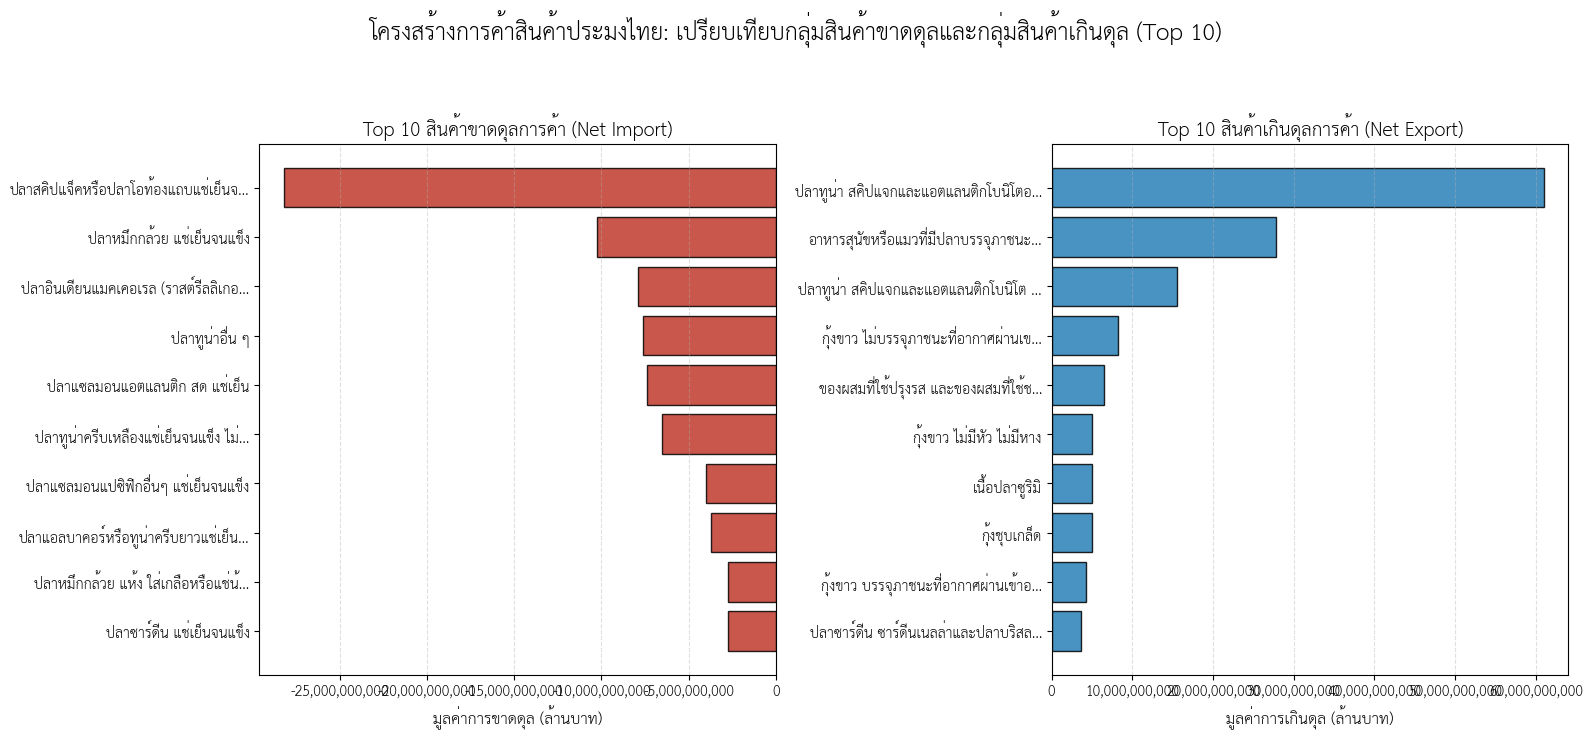

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False)
fig.suptitle('โครงสร้างการค้าสินค้าประมงไทย: เปรียบเทียบกลุ่มสินค้าขาดดุลและกลุ่มสินค้าเกินดุล (Top 10)', fontsize=16, fontweight='bold', y=1.05)

axes[0].barh(top_imports['short_name'], top_imports['net'], color='#c0392b', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 10 สินค้าขาดดุลการค้า (Net Import)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('มูลค่าการขาดดุล (ล้านบาท)', fontsize=11)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

axes[1].barh(top_exports['short_name'], top_exports['net'], color='#2980b9', edgecolor='black', alpha=0.85)
axes[1].set_title('Top 10 สินค้าเกินดุลการค้า (Net Export)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('มูลค่าการเกินดุล (ล้านบาท)', fontsize=11)
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

จากการวิเคราะห์ข้อมูลผ่านกราฟเปรียบเทียบ Top 10 สินค้าประมงที่ขาดดุลการค้า (Net Import) และสินค้าที่เกินดุลการค้า (Net Export) ของประเทศไทย สามารถถอดรหัสโครงสร้างทางเศรษฐกิจและรูปแบบการดำเนินธุรกิจของอุตสาหกรรมนี้ได้อย่างชัดเจน ดังประเด็นต่อไปนี้

### 1. โมเดลธุรกิจ "นำเข้าวัตถุดิบต้นน้ำ เพื่อส่งออกสินค้าปลายน้ำ" (The Processing Hub Model)
ความเชื่อมโยงที่ชัดเจนที่สุดจากกราฟทั้งสองฝั่งคืออุตสาหกรรม "ปลาทูน่า"

ฝั่งนำเข้า (ต้นทุน): ประเทศไทยมีสภาวะขาดดุลอย่างหนักในการนำเข้าวัตถุดิบปลาทูน่าแช่แข็งหลากหลายสายพันธุ์ ได้แก่ ปลาสคิปแจ็ค (อันดับ 1 ขาดดุลราว 2.7 หมื่นล้านบาท), ปลาทูน่าอื่นๆ (อันดับ 4), ปลาทูน่าครีบเหลือง (อันดับ 6) และปลาแอลบาคอร์ (อันดับ 8)

ฝั่งส่งออก (รายได้): เมื่อพิจารณาฝั่งเกินดุล กลับพบว่า "ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโต" (ซึ่งผ่านการแปรรูปหรือบรรจุกระป๋อง) ครองแชมป์สินค้าส่งออกอันดับ 1 ที่สร้างเม็ดเงินส่วนต่างได้สูงถึง 6 หมื่นล้านบาท และยังมีผลิตภัณฑ์ทูน่าแปรรูปรูปแบบอื่นในอันดับ 3 อีกราว 1.5 หมื่นล้านบาท

นัยยะเชิงวิเคราะห์: ข้อมูลนี้ยืนยันว่าประเทศไทยทำหน้าที่เป็น "โรงงานแปรรูปของโลก" เรายอมขาดดุลเพื่อนำเข้าทรัพยากรธรรมชาติที่เรามีไม่เพียงพอ เข้าสู่กระบวนการอุตสาหกรรมเพื่อสร้างมูลค่าเพิ่ม (Value-added) ก่อนส่งออก ซึ่งอัตรากำไรส่วนต่างที่ได้นั้นกว้างมาก (กำไรจากการส่งออกทูน่าแปรรูป สูงกว่าต้นทุนการนำเข้าทูน่าแช่แข็งกว่าเท่าตัว)

### 2. การประยุกต์ใช้ผลพลอยได้ขั้นสูง (By-product Utilization)
สินค้าเกินดุลการค้าอันดับที่ 2 คือ "อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะ" ซึ่งสร้างมูลค่าสุทธิได้สูงถึงราว 3 หมื่นล้านบาท สิ่งนี้สะท้อนถึงประสิทธิภาพของห่วงโซ่อุปทาน (Supply Chain Efficiency) ในอุตสาหกรรมประมงไทย ที่สามารถนำชิ้นส่วนหรือผลพลอยได้จากการแปรรูปทูน่าและสัตว์น้ำอื่นๆ มาต่อยอดเป็นอุตสาหกรรมอาหารสัตว์เลี้ยงที่กำลังเติบโตและมีมูลค่าสูงในตลาดโลกได้อย่างชาญฉลาด

### 3. ความแข็งแกร่งของห่วงโซ่อุปทาน "กุ้ง" ในประเทศ (Strength of Domestic Shrimp Supply Chain)
เมื่อวิเคราะห์ฝั่งสินค้าเกินดุล (ขวามือ) จะพบว่าผลิตภัณฑ์กลุ่ม "กุ้ง" เรียงแถวติดอันดับ Top 10 ถึง 4 รายการ ได้แก่ กุ้งขาวไม่บรรจุภาชนะ (อันดับ 4), กุ้งขาวไม่มีหัว/หาง (อันดับ 6), กุ้งชุบเกล็ด (อันดับ 8) และกุ้งขาวบรรจุภาชนะ (อันดับ 9) โดยที่สินค้ากลุ่มกุ้งเหล่านี้ไม่ปรากฏในฝั่งนำเข้าเลย สะท้อนให้เห็นว่าอุตสาหกรรมเพาะเลี้ยงและแปรรูปกุ้งของไทย มีความแข็งแกร่งตั้งแต่ต้นน้ำถึงปลายน้ำ สามารถพึ่งพาผลผลิตภายในประเทศได้ 100% และมีความหลากหลายในการแปรรูปเพื่อตอบสนองตลาดที่แตกต่างกัน

### 4. ข้อจำกัดทางภูมิศาสตร์และอุปสงค์สินค้าพรีเมียม (Geographic Constraints & Premium Demand)
กราฟฝั่งขาดดุล (ซ้ายมือ) เผยให้เห็นรอยรั่วของกระแสเงินสดที่เกิดจากข้อจำกัดทางสภาพภูมิอากาศ นั่นคือการนำเข้า "ปลาแซลมอนแอตแลนติกสด/แช่เย็น" (อันดับ 5) และ "ปลาแซลมอนแปซิฟิกอื่นๆ" (อันดับ 7) รวมมูลค่าการขาดดุลกว่า 1 หมื่นล้านบาท ข้อมูลส่วนนี้ชี้ให้เห็นถึงกำลังซื้อและพฤติกรรมการบริโภคภายในประเทศที่มีความต้องการอาหารทะเลระดับพรีเมียมสูงมาก ซึ่งเป็นกลุ่มสินค้าที่ไทยไม่สามารถใช้กลยุทธ์การผลิตเพื่อทดแทนการนำเข้า (Import Substitution) ได้

### บทสรุป:
ภาพรวมของกราฟชุดนี้ยืนยันว่า อุตสาหกรรมประมงและอาหารทะเลของไทยขับเคลื่อนด้วย "นวัตกรรมการแปรรูปอุตสาหกรรม" มากกว่าการพึ่งพาทรัพยากรทางธรรมชาติเพียงอย่างเดียว โครงสร้างการค้ามีความแข็งแกร่งในแง่ของการทำกำไรสุทธิระดับมหาศาลจากอุตสาหกรรมอาหารสัตว์และอาหารกระป๋อง อย่างไรก็ตาม ภาคส่วนนี้ยังต้องเผชิญกับความเสี่ยงจากต้นทุนวัตถุดิบนำเข้าที่ผันผวน (เช่น ราคาปลาทูน่าแช่แข็งในตลาดโลก) ซึ่งเป็นต้นน้ำสำคัญที่หล่อเลี้ยงโรงงานอุตสาหกรรมในประเทศ

## Seasonal Trade Pattern
ในส่วนนี้ จะทำการวิเคราะห์พลวัตและแนวโน้มการค้าสินค้าประมงของประเทศไทยในเชิงอนุกรมเวลา (Time-Series Analysis) โดยใช้ข้อมูลรายเดือนตลอดปี 2568 เพื่อประเมินวัฏจักรทางเศรษฐกิจและปัจจัยทางฤดูกาลที่ส่งผลกระทบต่ออุตสาหกรรม

**วัตถุประสงค์ของการวิเคราะห์:**
1. **ติดตามความผันผวนทางเศรษฐกิจ:** เพื่อประเมินทิศทางการเปลี่ยนแปลงของมูลค่าการนำเข้าและส่งออกในแต่ละช่วงเดือน
2. **ระบุจุดสูงสุดและต่ำสุดของวัฏจักร (Peak & Trough Analysis):** เพื่อค้นหาช่วงเวลาที่อุตสาหกรรมมีความคึกคักสูงสุด และช่วงเวลาที่ชะลอตัว
3. **วิเคราะห์ความสัมพันธ์เชิงฤดูกาล:** เพื่อเชื่อมโยงข้อมูลเชิงประจักษ์กับปัจจัยแวดล้อม เช่น ฤดูกาลจับสัตว์น้ำ วัฏจักรการเพาะเลี้ยง หรือเทศกาลบริโภคระดับโลก

**ระเบียบวิธีวิเคราะห์ (Analytical Approach):**
กระบวนการนี้จะทำการรวมสถิติมูลค่าการค้า (Price) โดยจำแนกตามเดือน (Month) และประเภทการดำเนินธุรกรรม (Import/Export) จากนั้นนำเสนอผ่านแผนภูมิเส้น (Line Chart) เพื่อแสดงให้เห็นถึงทิศทาง (Trend) และรูปแบบความผันผวน (Seasonality Pattern) ของกระแสเงินสดในระบบอุตสาหกรรมอย่างเป็นรูปธรรม

In [104]:
monthly_trade = df.pivot_table(
    index='month',
    columns='tradeflow',
    values='price',
    aggfunc='sum'
).fillna(0)

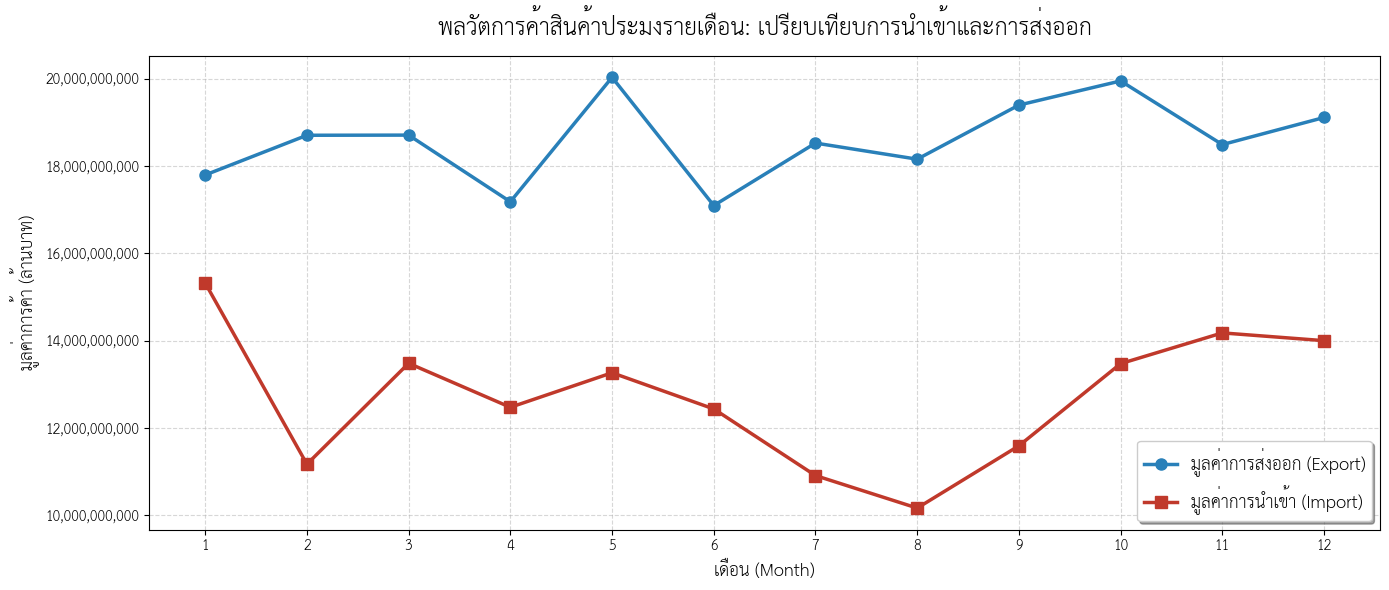

In [105]:
fig, ax = plt.subplots(figsize=(14, 6))

if 'Export' in monthly_trade.columns:
    ax.plot(monthly_trade.index, monthly_trade['Export'],
            marker='o', markersize=8, linewidth=2.5,
            color='#2980b9', label='มูลค่าการส่งออก (Export)')

if 'Import' in monthly_trade.columns:
    ax.plot(monthly_trade.index, monthly_trade['Import'],
            marker='s', markersize=8, linewidth=2.5,
            color='#c0392b', label='มูลค่าการนำเข้า (Import)')

ax.set_title('พลวัตการค้าสินค้าประมงรายเดือน: เปรียบเทียบการนำเข้าและการส่งออก', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('เดือน (Month)', fontsize=12)
ax.set_ylabel('มูลค่าการค้า (ล้านบาท)', fontsize=12)

ax.set_xticks(range(1, 13))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='best', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

จากการวิเคราะห์ข้อมูลอนุกรมเวลา (Time-Series Analysis) แสดงมูลค่าการนำเข้าและส่งออกสินค้าประมงตลอดทั้งปีผ่านแผนภูมิเส้น สามารถถอดรหัสพฤติกรรมทางเศรษฐกิจและวัฏจักรของอุตสาหกรรม (Industry Cycle) ได้ใน 4 ประเด็นหลัก ดังนี้

### 1. สถานะการเกินดุลเชิงโครงสร้างที่แข็งแกร่งตลอดปี (Year-Round Structural Surplus)
ภาพรวมที่เด่นชัดที่สุดจากแผนภูมิคือ เส้นมูลค่าการส่งออก (สีน้ำเงิน) ทิ้งระยะห่างและอยู่เหนือเส้นมูลค่าการนำเข้า (สีแดง) อย่างชัดเจนในทุกๆ เดือน โดยมีส่วนต่าง (Margin) การเกินดุลเฉลี่ยอยู่ที่ 4,000 - 8,000 ล้านบาทต่อเดือน ปรากฏการณ์นี้เป็นหลักฐานเชิงประจักษ์ที่ยืนยันว่า อุตสาหกรรมประมงของไทยทำงานด้วยโมเดล "ศูนย์กลางการแปรรูปและเพิ่มมูลค่า (Value-Added Processing Hub)" อย่างแท้จริง โดยไม่สูญเสียความสามารถในการทำกำไรในเดือนใดเลยตลอดทั้งปี

### 2. วัฏจักรการส่งออกและฤดูกาลบริโภคของตลาดโลก (Export Cycles & Global Demand)
การพุ่งขึ้นของมูลค่าการส่งออกมีรูปแบบ (Pattern) ที่สอดคล้องกับฤดูกาลบริโภคของตลาดโลกอย่างมีนัยสำคัญ:

จุดสูงสุดที่ 1 (เดือนพฤษภาคม): มูลค่าการส่งออกพุ่งแตะระดับสูงสุดที่ประมาณ 20,000 ล้านบาท ซึ่งสะท้อนถึงการเร่งส่งมอบสินค้าเพื่อรองรับอุปสงค์ในช่วงกลางปีของตลาดคู่ค้า

จุดสูงสุดที่ 2 (เดือนตุลาคม): การส่งออกไต่ระดับขึ้นอย่างต่อเนื่องตั้งแต่เดือนกรกฎาคม และไปทำจุดสูงสุดอีกครั้งในเดือนตุลาคมที่ระดับเกือบ 20,000 ล้านบาท วัฏจักรนี้คือ "ช่วงเวลาทอง (High Season)" ของอุตสาหกรรมอาหารส่งออก ที่ต้องเร่งผลิตและส่งมอบสินค้าเข้าสู่คลังของกลุ่มประเทศตะวันตก (โดยเฉพาะสหรัฐอเมริกาและยุโรป) เพื่อเตรียมพร้อมสำหรับเทศกาลเฉลิมฉลองในช่วงไตรมาสที่ 4 (Thanksgiving, Christmas และ New Year)

ช่วงชะลอตัว (เดือนเมษายน และ มิถุนายน): การปรับตัวลดลงในเดือนเมษายนอาจเป็นผลกระทบเชิงฤดูกาลภายในประเทศ (วันหยุดยาวเทศกาลสงกรานต์) ที่ทำให้จำนวนวันทำงานและรอบโลจิสติกส์ลดลงชั่วคราว

### 3. วัฏจักรการนำเข้าวัตถุดิบและการบริหารสินค้าคงคลัง (Import Cycles & Inventory Management)
ฝั่งการนำเข้าสะท้อนรอบการทำงานของภาคการผลิต (Manufacturing Cycle) ได้อย่างน่าสนใจ:

การเร่งกักตุนต้นปี (เดือนมกราคม): มูลค่าการนำเข้าเริ่มต้นปีด้วยจุดสูงสุดที่กว่า 15,000 ล้านบาท บ่งชี้ว่าผู้ประกอบการและโรงงานแปรรูปเร่งนำเข้าวัตถุดิบ (เช่น ปลาทูน่าแช่แข็ง) เข้ามาสต็อกไว้เป็นจำนวนมาก เพื่อเตรียมความพร้อมสำหรับสายการผลิตในไตรมาสที่ 1 และ 2

จุดต่ำสุดของปี (เดือนสิงหาคม): มูลค่าการนำเข้าดิ่งลงสู่จุดต่ำสุดที่ระดับ 10,000 ล้านบาท ซึ่งเป็นช่วงที่โรงงานน่าจะใช้ทรัพยากรจากสินค้าคงคลังที่มีอยู่เป็นหลัก ก่อนที่จะเริ่มไต่ระดับการนำเข้าวัตถุดิบขึ้นอีกครั้งในช่วงปลายปี (เดือนกันยายนถึงพฤศจิกายน) เพื่อเตรียมรอบการผลิตสำหรับปีถัดไป

### 4. ปรากฏการณ์เหลื่อมเวลาของห่วงโซ่อุปทาน (Supply Chain Time-Lag Phenomenon)
เมื่อพิจารณาความสัมพันธ์ของเส้นกราฟทั้งสอง จะพบความเชื่อมโยงในลักษณะ "ระยะเวลาหน่วง (Lag Time)" ตัวอย่างเช่น การเร่งนำเข้าวัตถุดิบอย่างหนักในเดือนมกราคม ส่งผลให้เกิดการผลิตและผลักดันยอดส่งออกให้พุ่งสูงขึ้นในช่วงเดือนกุมภาพันธ์ถึงพฤษภาคม ในขณะที่ยอดนำเข้าที่เริ่มปรับตัวสูงขึ้นตั้งแต่เดือนกันยายนจนถึงปลายปี ก็เป็นเสมือนตัวชี้วัดนำ (Leading Indicator) ที่แสดงให้เห็นการเตรียมพร้อมของภาคอุตสาหกรรมสำหรับรอบการส่งออกในช่วงต้นปีถัดไป

### นัยยะเชิงกลยุทธ์ (Strategic Implications):
ข้อมูลชุดนี้สะท้อนให้เห็นว่า ผู้ประกอบการในอุตสาหกรรมประมงไทยมีทักษะในการบริหารจัดการห่วงโซ่อุปทาน (Supply Chain Management) ในระดับสูง ความท้าทายสำคัญที่ผู้มีอำนาจตัดสินใจทางธุรกิจต้องเฝ้าระวังคือ "การบริหารสภาพคล่องทางการเงิน (Cash Flow Management)" ในช่วงเดือนที่มีการเร่งนำเข้าวัตถุดิบสูง (เช่น เดือนมกราคม) และการบริหารพื้นที่จัดเก็บสินค้าคงคลังให้มีประสิทธิภาพสูงสุด เพื่อรองรับความผันผวนของราคาวัตถุดิบในตลาดโลกที่อาจเกิดขึ้นในแต่ละช่วงเวลาของปี